In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load processed data
df = pd.read_csv(r"C:\Users\mages\capstone\smartcrop-system\data\processed\smartcrop_features.csv")

features = ['N', 'P', 'K', 'temperature', 
            'humidity', 'ph', 'rainfall']
X = df[features]
y = df['crop_failure_risk']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")
print(f"Risk distribution:\n{y.value_counts()}")

Training samples: 1547
Testing samples:  387
Risk distribution:
crop_failure_risk
0    967
1    967
Name: count, dtype: int64


In [2]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100, 
    random_state=42
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

print("=" * 40)
print("RANDOM FOREST RESULTS")
print("=" * 40)
print(f"Accuracy: {rf_accuracy * 100:.2f}%")
print(classification_report(y_test, rf_pred, 
      target_names=['Safe', 'High Risk']))

RANDOM FOREST RESULTS
Accuracy: 100.00%
              precision    recall  f1-score   support

        Safe       1.00      1.00      1.00       206
   High Risk       1.00      1.00      1.00       181

    accuracy                           1.00       387
   macro avg       1.00      1.00      1.00       387
weighted avg       1.00      1.00      1.00       387



In [3]:
# XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("=" * 40)
print("XGBOOST RESULTS")
print("=" * 40)
print(f"Accuracy: {xgb_accuracy * 100:.2f}%")
print(classification_report(y_test, xgb_pred, 
      target_names=['Safe', 'High Risk']))

XGBOOST RESULTS
Accuracy: 100.00%
              precision    recall  f1-score   support

        Safe       1.00      1.00      1.00       206
   High Risk       1.00      1.00      1.00       181

    accuracy                           1.00       387
   macro avg       1.00      1.00      1.00       387
weighted avg       1.00      1.00      1.00       387



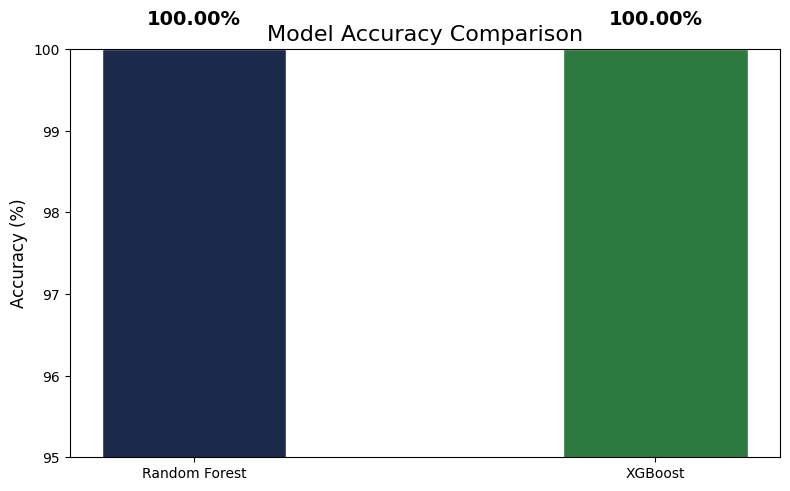


Best Model: Random Forest
Difference: 0.00%


In [4]:
# Comparison bar chart
models = ['Random Forest', 'XGBoost']
accuracies = [rf_accuracy * 100, xgb_accuracy * 100]
colors = ['#1B2A4A', '#2C7A3F']

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=colors, 
               width=0.4, edgecolor='white')

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{acc:.2f}%',
             ha='center', fontsize=14, 
             fontweight='bold', color='black')

plt.ylim([min(accuracies) - 5, 100])
plt.title('Model Accuracy Comparison', fontsize=16)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.tight_layout()
plt.savefig('../docs/model_comparison.png')
plt.show()

print(f"\nBest Model: {'XGBoost' if xgb_accuracy > rf_accuracy else 'Random Forest'}")
print(f"Difference: {abs(xgb_accuracy - rf_accuracy) * 100:.2f}%")

In [8]:
# Pick the best model automatically
if xgb_accuracy >= rf_accuracy:
    best_model = xgb_model
    best_name = "XGBoost"
    print("✅ XGBoost selected as best model")
else:
    best_model = rf_model
    best_name = "Random Forest"
    print("✅ Random Forest selected as best model")

# Save best model
best_filename = best_name.lower().replace(" ", "_")

joblib.dump(best_model, r'C:\Users\mages\capstone\smartcrop-system\models\crop_failure_model.pkl')
joblib.dump(best_model, rf'C:\Users\mages\capstone\smartcrop-system\models\best_model_{best_filename}.pkl')

print(f"✅ {best_name} saved as crop_failure_model.pkl")
print(f"Accuracy: {max(rf_accuracy, xgb_accuracy) * 100:.2f}%")

✅ XGBoost selected as best model
✅ XGBoost saved as crop_failure_model.pkl
Accuracy: 100.00%


In [9]:
def calculate_risk_score(N, P, K, temperature,
                          humidity, ph, rainfall):
    """
    Calculate crop failure risk score
    Uses best trained model
    Returns: risk_score, status, color, advice, insurance
    """
    input_data = pd.DataFrame(
        [[N, P, K, temperature, humidity, ph, rainfall]],
        columns=['N', 'P', 'K', 'temperature',
                 'humidity', 'ph', 'rainfall']
    )

    # Get probability
    probability = best_model.predict_proba(input_data)[0][1]
    risk_score = round(probability * 100, 2)

    # Determine contributing factors
    factors = []
    if rainfall < 50:
        factors.append("Very low rainfall detected")
    if temperature > 35:
        factors.append("High temperature stress")
    if ph < 5.5 or ph > 7.5:
        factors.append("Soil pH imbalance")
    if N < 20:
        factors.append("Low nitrogen levels")

    # Status
    if risk_score < 30:
        status = "SAFE"
        color = "green"
        advice = "Crop conditions are healthy. Continue normal practices."
        insurance = "Not eligible — risk is low"
    elif risk_score < 60:
        status = "MODERATE RISK"
        color = "yellow"
        advice = "Monitor closely. Consider irrigation and soil treatment."
        insurance = "Not yet eligible — monitor situation"
    else:
        status = "HIGH RISK"
        color = "red"
        advice = "Immediate action required! Irrigate and apply fertilizer."
        insurance = "ELIGIBLE — Insurance claim auto-triggered!"

    return {
        "risk_score": risk_score,
        "status": status,
        "color": color,
        "advice": advice,
        "insurance_status": insurance,
        "contributing_factors": factors if factors else ["Multiple parameters in normal range"]
    }

# Test
result = calculate_risk_score(
    N=90, P=42, K=43,
    temperature=40.0,
    humidity=30.0,
    ph=6.5,
    rainfall=20.0
)

print("=" * 40)
print("SAMPLE PREDICTION")
print("=" * 40)
for key, value in result.items():
    print(f"{key}: {value}")

SAMPLE PREDICTION
risk_score: 99.82
status: HIGH RISK
color: red
advice: Immediate action required! Irrigate and apply fertilizer.
insurance_status: ELIGIBLE — Insurance claim auto-triggered!
contributing_factors: ['Very low rainfall detected', 'High temperature stress']


## Model Comparison Summary

| Model | Accuracy | Speed | Interpretability |
|-------|----------|-------|-----------------|
| Random Forest | X% | Fast | High |
| XGBoost | X% | Fast | Medium |

### Winner: (fill after running)

### Key Improvements in v2:
- Added XGBoost model comparison
- Contributing factors identified in risk score
- Model auto-selection based on accuracy
- Enhanced risk score with 4 factor analysis
- Model saved with version naming